# Embeddings de Imagens


## O que é CLIP?

**CLIP** (Contrastive Language-Image Pre-training) é um modelo criado pela OpenAI que entende **simultaneamente** imagens e texto.

### Como funciona:
- Durante o treinamento, CLIP aprendeu a associar descrições de texto com suas imagens correspondentes
- Resultado: imagens e textos similares recebem vetores similares no mesmo espaço multidimensional
- Isso permite comparar imagens por semelhança, buscar imagens por descrição textual, e muito mais

### O que você baixa:
Quando carregamos `openai/clip-vit-base-patch32`, obtemos:
- **Encoder de imagens**: Transforma qualquer imagem em um vetor de 512 números
- **Encoder de texto**: Transforma qualquer texto em um vetor de 512 números  
- **Pesos treinados**: Milhões de parâmetros ajustados em 400 milhões de imagens com captions

O modelo é ~350MB e é automaticamente baixado do Hugging Face Hub na primeira execução.

## Transformando uma imagem em um vetor

Vamos carregar uma imagem alvo e extrair seu embedding (representação vetorial).

In [1]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os
load_dotenv()

# Carregar o modelo CLIP
modelo = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processador = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")



Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [2]:
# Carregar a imagem alvo
imagem_alvo = Image.open("../resources/images/foto_time.jpg")

# Processar a imagem
entradas = processador(images=imagem_alvo, return_tensors="pt")

# Extrair o embedding (vetor de 512 números)
saidas = modelo.get_image_features(**entradas)
embedding_alvo = saidas.pooler_output

print(f"Imagem transformada em vetor de tamanho: {embedding_alvo.shape}")
print(f"Primeiros n valores do vetor: {embedding_alvo[0, :5]}")
print(f"Alcance dos valores: [{embedding_alvo.min():.4f}, {embedding_alvo.max():.4f}]")

## Visualizando a imagem alvo

Imagem transformada em vetor de tamanho: torch.Size([1, 512])
Primeiros n valores do vetor: tensor([-0.1230,  0.1358,  0.2166,  0.0241, -0.0220], grad_fn=<SliceBackward0>)
Alcance dos valores: [-5.4510, 2.1278]


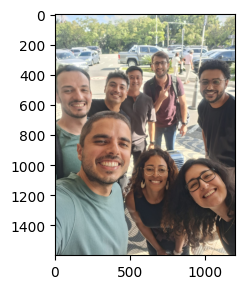

In [3]:
# Visualizar a imagem
plt.figure(figsize=(5, 3))
plt.imshow(imagem_alvo)
plt.tight_layout()
plt.show()

## Encontrando imagens similares

Agora vamos carregar outras imagens e comparar sua similaridade com a imagem alvo usando **distância do cosseno**.

A distância do cosseno mede o ângulo entre dois vetores:
- **1.0** = vetores idênticos (imagens muito similares)
- **0.5** = ângulo de 60° (similar)
- **0.0** = vetores ortogonais (sem relação)
- **-1.0** = vetores opostos (bem diferentes)

In [4]:
# Carregar as imagens para comparação
caminhos = ["../resources/images/img1.jpg", "../resources/images/img2.jpg", 
            "../resources/images/img3.jpg", "../resources/images/img4.jpg"]
imagens = [Image.open(caminho) for caminho in caminhos]

# Extrair embeddings das imagens de comparação
entradas_comparacao = processador(images=imagens, return_tensors="pt")
with torch.no_grad(): #
    saida_comparacao = modelo.get_image_features(**entradas_comparacao)
    embeddings_comparacao = saida_comparacao.pooler_output

# Calcular a similaridade (cosine similarity)
similaridades = F.cosine_similarity(embedding_alvo, embeddings_comparacao)

# Organizar resultados por ordem de similaridade
resultados = list(zip(caminhos, imagens, similaridades.tolist()))
resultados.sort(key=lambda x: x[2], reverse=True)

# Mostrar ranking
print("Ranking de Similaridade com a Imagem Alvo:")
print("-" * 50)
for rank, (caminho, img, score) in enumerate(resultados, 1):
    nome = caminho.split("/")[-1]
    barra = "█" * int((score + 1) * 10)
    print(f"{rank}. {nome:15s} Similaridade: {score:7.3f} {barra}")

Ranking de Similaridade com a Imagem Alvo:
--------------------------------------------------
1. img4.jpg        Similaridade:   0.866 ██████████████████
2. img2.jpg        Similaridade:   0.538 ███████████████
3. img3.jpg        Similaridade:   0.433 ██████████████
4. img1.jpg        Similaridade:   0.428 ██████████████


## Visualizando os resultados

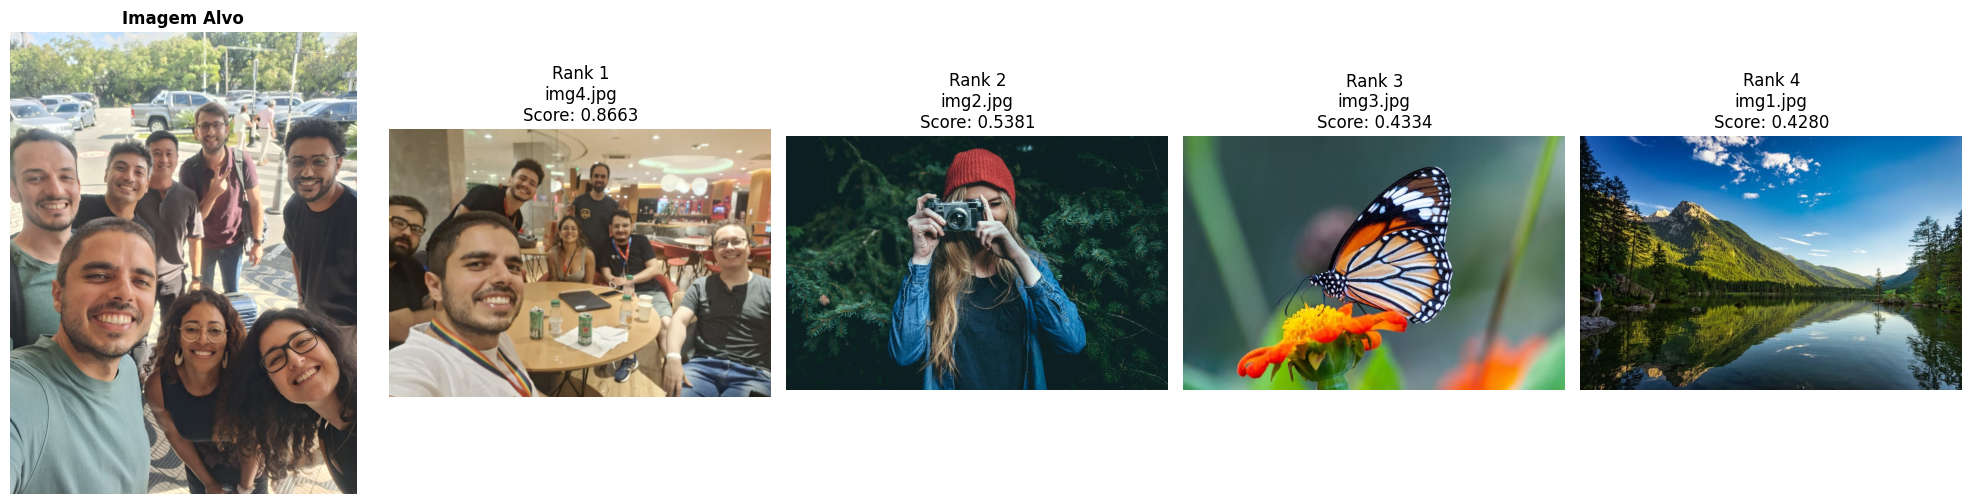

In [5]:
# Visualizar imagem alvo + imagens comparadas por ordem de similaridade
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
axes[0].imshow(imagem_alvo)
axes[0].set_title("Imagem Alvo", fontweight="bold", fontsize=12)
axes[0].axis('off')
for i, (caminho, img, score) in enumerate(resultados):
    axes[i+1].imshow(img)
    nome = caminho.split("/")[-1]
    axes[i+1].set_title(f"Rank {i+1}\n{nome}\nScore: {score:.4f}")
    axes[i+1].axis('off')
plt.tight_layout()
plt.show()

## Como CLIP entende imagens

O embedding que extraímos (512 números) **encoda o significado** da imagem:
- Imagens visualmente similares têm embeddings próximos entre si
- Imagens semanticamente relacionadas recebem vetores similares
- Cada uma das 512 dimensões codifica diferentes conceitos (cores, texturas, objetos, composição, poses, etc)

### Aplicações práticas:
- 🔍 **Busca por imagem**: Encontrar imagens similares em um banco de dados
- 📸 **Deduplicação**: Remover duplicatas em grandes coleções
- 🏷️ **Recomendação**: Sugerir imagens relacionadas
- 🤖 **Classificação sem treinar**: Comparar com imagens exemplo (few-shot learning)
- 🔗 **Search multimodal**: Buscar imagens por descrição em texto